# Nuclear Statistical Equilibrium

In [1]:
import pynucastro as pyna
import warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

## Constructing the network

Let's recreate the aprox13 network following `aprox13.ipynb`, but using rates from the `StarLib` library instead of `ReacLib` this time.

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"], 
                          main_library="starlib")

Note that all reverse rates were automatically recomputed using the built-in `DerivedRate` class to ensure NSE compatibility.

We can make additional approximations such as $(\alpha,p)(p, \gamma)$, $(n, \gamma)(n, \gamma)$ and C12 and O16 burning approximations.

In [3]:
net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

net.make_nn_g_approx(intermediate_nuclei=["fe53"])
net.remove_nuclei(["fe53"])

net.make_CO_burning_approx(root_nuclei="C")
net.remove_nuclei(["na23"])
net.make_CO_burning_approx(root_nuclei="CO")
net.remove_nuclei(["al27"])
net.make_CO_burning_approx(root_nuclei="O")
net.remove_nuclei(["p31"])

We now have the same `aprox13` network, but this time using rates from `Starlib` library.

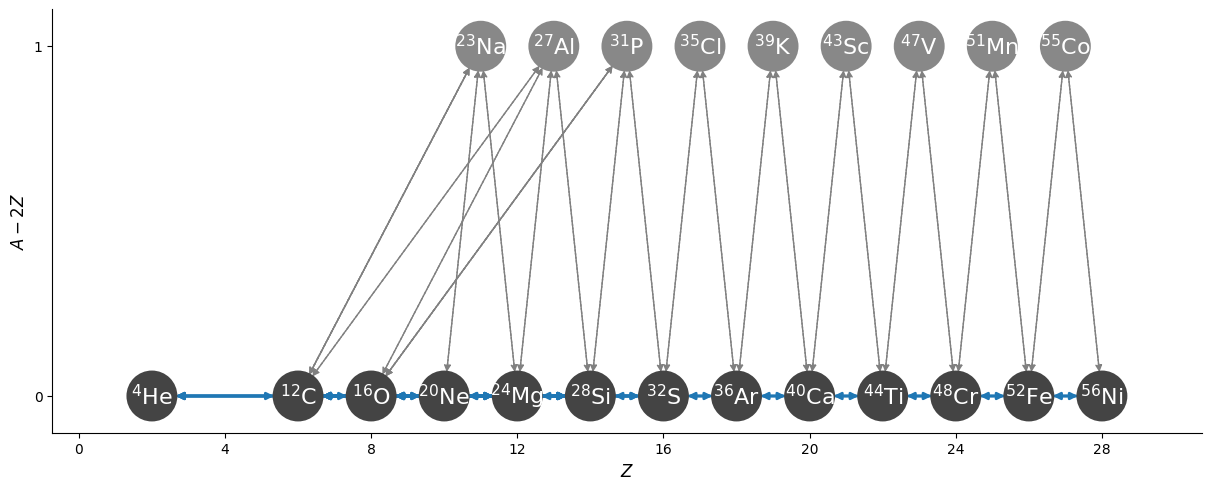

In [4]:
fig = net.plot(rotated=True, hide_xalpha=True,
               size=(1200, 500), node_size=1200, node_font_size=16)

We can look at some properties have the reaction network that we created via the `summary()` method. 
It also checks whether the network is intrinsically compatible with NSE. 

In [5]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 13
  approximated-out nuclei: 9
  inert nuclei (included in carried): 0

  NSE compatible? True

  total number of rates: 104

  rates explicitly connecting nuclei: 38
  hidden rates: 66

  reaclib rates: 0
  starlib rates: 37
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 30
  derived rates: 37
  modified rates: 0
  custom rates: 0


You can explicitly call the `is_NSE_compatible()` method to see whether the network is compatible with NSE. This method checks
whether all the nuclei are sufficiently connected and whether all rates have a corresponding inverse rate computed from detailed-balance.

In [6]:
net.is_NSE_compatible(verbose=True)

NSE Compatibility Summary 
-------------------------
  Nullity: 1
  Rank: 12
  Max allowed dimension: 1
  Number of species: 13



np.True_

## Integration

Now we want to integrate to steady state. Let's use an uniform initial composition. We will use a tight tolerance close to machine precision to show case machine precision compatibility.

In [7]:
np.random.seed(1234)

In [8]:
rho = 1e7
T = 6e9
sl_sol = net.integrate_network(tmax=1.e-1, rho=rho, T=T, initial_comp="uniform", 
                            screen_method="potekhin_1998", rtol=3.e-14, atol=3.e-14)

Let's resample the rate

In [9]:
data = []
nsamples = 15
for seed in np.random.randint(0, 1000, nsamples):
    net.resample(seed=seed)
    sol = net.integrate_network(tmax=1.e-1, rho=rho, T=T, initial_comp="uniform", 
                                screen_method="potekhin_1998", rtol=1.e-12, atol=1.e-12)
    data.append(sol)

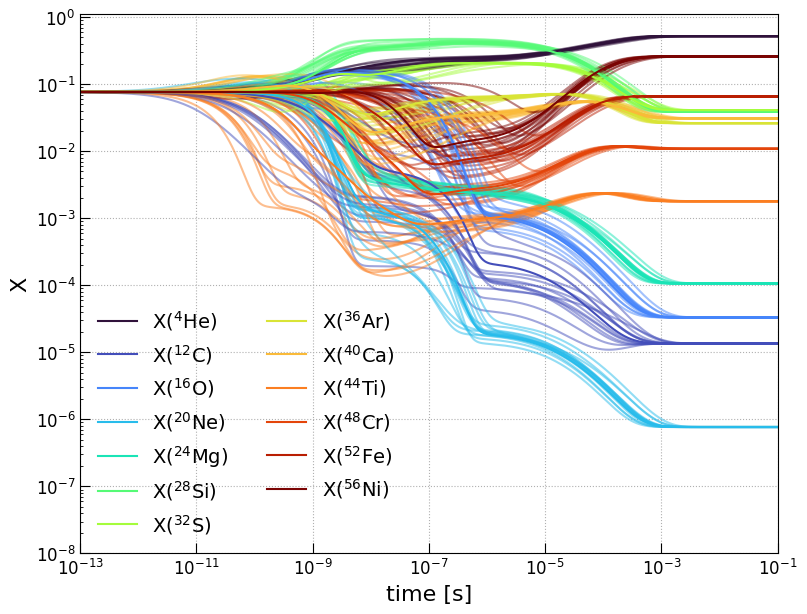

In [10]:
n_nuc = len(sl_sol.unique_nuclei)
cmap = plt.get_cmap("turbo")
colors = cmap(np.linspace(0, 1, n_nuc))
nuc_colors = {nuc: colors[i % len(colors)] for i, nuc in enumerate(sl_sol.unique_nuclei)}

fig, ax = plt.subplots(figsize=(9, 7))

# sampled StarLib rates
for sol in data:
    for i, nuc in enumerate(sol.unique_nuclei):
        ax.loglog(sol.t, sol.X[i, :], alpha=0.5,
                 color=nuc_colors[nuc])

# median StarLib rates
for i, nuc in enumerate(sl_sol.unique_nuclei):
    ax.loglog(sl_sol.t, sl_sol.X[i, :],
              color=nuc_colors[nuc],
              label=f"X(${nuc.pretty}$)")

ax.set_xlim(1.e-13, 1.e-1)
ax.set_ylim(1.e-8, 1.1)
ax.legend(fontsize=14, ncol=2, frameon=False)
ax.set_xlabel("time [s]", fontsize=16)
ax.set_ylabel("X", fontsize=16)
ax.tick_params(labelsize=12, size=7)
ax.tick_params(which="both", direction="in")
ax.grid(ls=":")
fig.savefig("nse-evolution.png", format="png", bbox_inches="tight")

We can plot to see how the species mass fractions evolve over time. We see that the evolution reaches a steady state in the end, indicated by the flat lines. We also see that the steady state solution is independentof the sampled rates. This is because at equilibrium,
the ratio of the forward and reverse rates are always fixed based on the properties of the reactants and products after re-deriving the inverse rate using detailed balance.

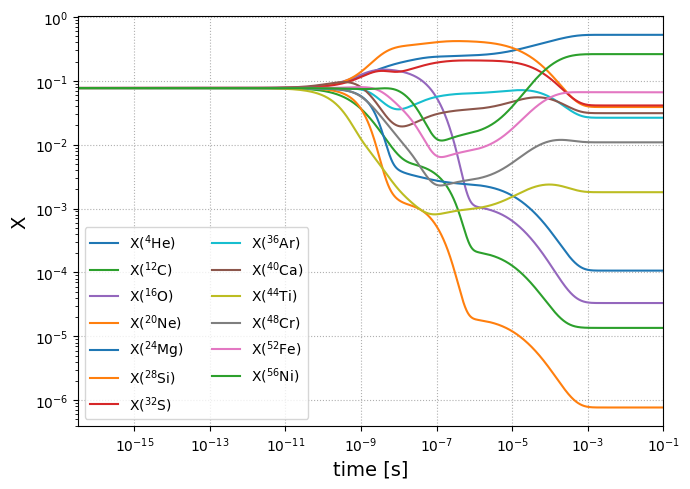

In [11]:
fig = sl_sol.plot_evolution(size=(700, 500))

## NSE Comparison

Now let's solve for the corresponding NSE-state and see how it compares to the steady state solution.

In [14]:
def NSE_comparison(mynet, sol, rho=1e7, T=6e9):

    # Create the NSENetwork
    nse_net = pyna.NSENetwork(rates=mynet.get_rates())

    # Compute electron fraction assuming uniform composition.
    # This is to avoid numerical error deviating from the initial electron fraction
    ye = sum(nuc.Z / nuc.A for i, nuc in enumerate(mynet.unique_nuclei)) / len(mynet.unique_nuclei)
    
    # Compute the NSE state
    nse_comp = nse_net.get_comp_nse(rho, T, ye, init_guess=(-3.5, -14.0), use_coulomb_corr=True, tol=1e-12)

    # Make plots to see comparison between the two results
    As = np.array([nuc.A for nuc in mynet.unique_nuclei])
    X_net = sol.Y[:,-1]*As
    X_nse = np.array(list(nse_comp.X.values()))
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 9), sharex=True)
    nuc_labels = [rf"${nuc.pretty}$" for nuc in mynet.unique_nuclei]
    
    # Abundance Histogram plot
    x = np.arange(len(mynet.unique_nuclei))
    width = 0.35
    
    ax1.bar(x - width/2.0, X_nse, width, label = 'NSE')
    ax1.bar(x + width/2.0, X_net, width, label = 'Integration')
    
    ax1.set_ylabel("X", fontsize=14)
    ax1.set_yscale("log")
    ax1.set_ylim(ymax=1)
    ax1.legend(fontsize=14)
    ax1.tick_params(axis='y', labelsize=14) 

    # Error plot
    diff = np.abs(X_net - X_nse) 
    diff_rel = diff / X_net
    
    ax2.scatter(x, diff, label='Absolute Error', marker='o', color='tab:red', s=50)
    ax2.scatter(x, diff_rel, label='Relative Error', marker ='x', color='tab:blue', s=50)
    
    ax2.set_xlabel("Nucleus", fontsize=14)
    ax2.set_ylabel("Error", fontsize=14)
    ax2.set_yscale("log")
    ax2.set_ylim(ymax=1.01)
    ax2.grid(ls=":")
    ax2.legend(fontsize=14)

    ax2.tick_params(axis='y', labelsize=14) 
    ax2.set_xticks(x, labels=nuc_labels, rotation=90, fontsize=14)
    fig.tight_layout()
    fig.savefig("nse_comparison.png", format="png", bbox_inches="tight")

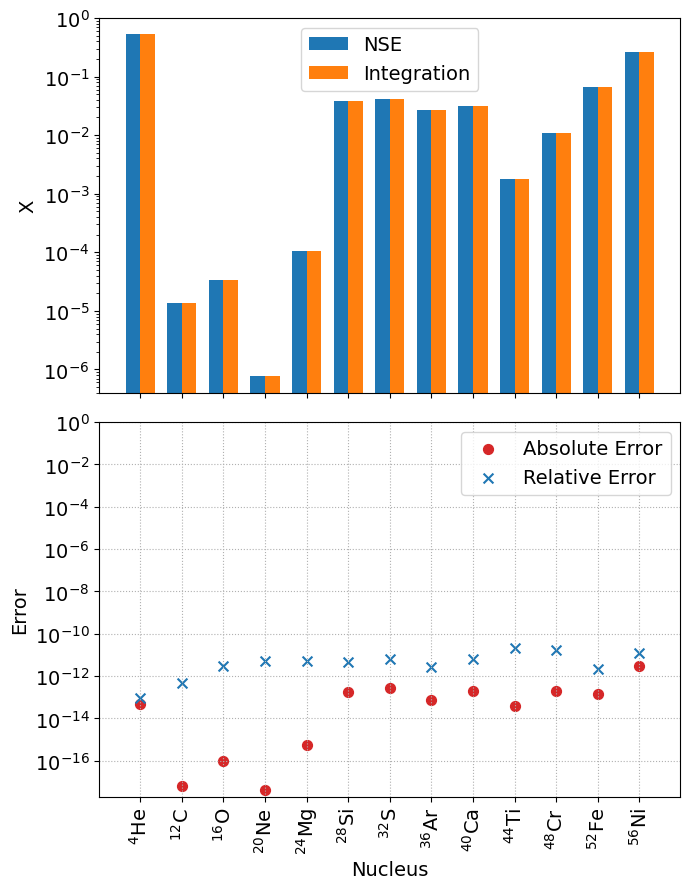

In [15]:
NSE_comparison(net, sl_sol, rho=rho, T=T)

We see machine-level precision between the steady state and NSE solutions.